# Regime-Switching SSMs with `RSSSM` (K = 3)

The [K = 2 tutorial](rsssm_regime_switching.ipynb) introduced regime-switching SSMs with `hssm.RSSSM` for a single participant alternating between two cognitive states, and reproduced the entire hand-built [HMM-DDM tutorial](hmm_ddm_regime_switching.ipynb) — including both the analytical and LAN emission backends — using the class.

This tutorial runs the **same workflow at $K = 3$** (still a single participant): simulation, the forward-algorithm likelihood, NUTS fitting, FFBS regime recovery, transition-matrix recovery, and RT-by-regime. Three regimes also make a methodological point sharp — the way `RSSSM` breaks label-switching is *essential* at $K \ge 3$, where the naive approach fails — and they motivate a question the class lets us answer: **how many regimes does the data support?** We address it with LOO model comparison.

**The model.** For one participant with $K = 3$ regimes:

$$s_t \mid s_{t-1} \sim \text{Categorical}(P_{s_{t-1},\,\cdot}), \qquad (rt_t, \text{resp}_t) \mid s_t = k \sim \text{DDM}(v_k, a, z, t),$$

with the drift $v$ switching across regimes and $a, z, t$ shared.

## Part 1: Setup
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

import hssm

np.random.seed(0)

## Part 2: Simulate three-regime data
---
500 trials from three regimes with well-separated drift rates $v = [-1.0,\ 0.5,\ 1.8]$ — *conservative* (favours the lower boundary), *neutral*, and *eager* (favours the upper boundary). $a=1.0$, $z=0.5$, $t=0.3$ are shared; the regime sequence follows a sticky 3-state chain.

In [2]:
def simulate_regime_switching_ddm(n_trials, v_per_regime, a, z, t, P, pi0, seed=0):
    rng = np.random.default_rng(seed)
    K = len(v_per_regime)
    regimes = np.empty(n_trials, dtype=int)
    regimes[0] = rng.choice(K, p=pi0)
    for i in range(1, n_trials):
        regimes[i] = rng.choice(K, p=P[regimes[i - 1]])
    data = np.empty((n_trials, 2))
    for k in range(K):
        m = regimes == k
        n_k = int(m.sum())
        if n_k:
            data[m] = hssm.simulate_data(
                model="ddm", theta={"v": v_per_regime[k], "a": a, "z": z, "t": t},
                size=n_k, random_state=seed + k, output_df=False,
            )
    return pd.DataFrame(data, columns=["rt", "response"]), regimes


N_TRIALS = 500
V_TRUE, A_TRUE, Z_TRUE, T_TRUE = [-1.0, 0.5, 1.8], 1.0, 0.5, 0.3
P_TRUE = np.array([[0.90, 0.05, 0.05], [0.05, 0.90, 0.05], [0.05, 0.05, 0.90]])
PI0_TRUE = np.ones(3) / 3
df, true_regimes = simulate_regime_switching_ddm(
    N_TRIALS, V_TRUE, A_TRUE, Z_TRUE, T_TRUE, P_TRUE, PI0_TRUE, seed=1
)
df.head()

,rt,response
0,1.072343,1.0
1,1.076137,1.0
2,0.545454,1.0
3,0.657068,1.0
4,0.808315,1.0


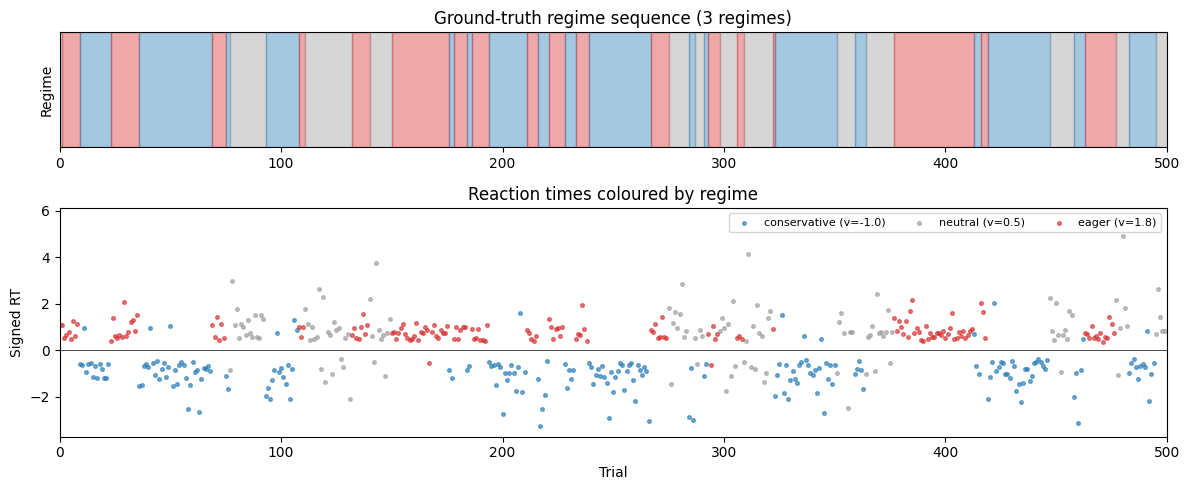

In [3]:
colors = {0: "#1f77b4", 1: "#999999", 2: "#d62728"}
names = {0: "conservative (v=-1.0)", 1: "neutral (v=0.5)", 2: "eager (v=1.8)"}
fig, axes = plt.subplots(2, 1, figsize=(12, 5), gridspec_kw={"height_ratios": [1, 2]})
trials = np.arange(N_TRIALS)
ax = axes[0]; start = 0
for i in range(1, N_TRIALS + 1):
    if i == N_TRIALS or true_regimes[i] != true_regimes[start]:
        ax.axvspan(start, i, alpha=0.4, color=colors[true_regimes[start]]); start = i
ax.set_xlim(0, N_TRIALS); ax.set_yticks([]); ax.set_ylabel("Regime")
ax.set_title("Ground-truth regime sequence (3 regimes)")
ax = axes[1]
for k in (0, 1, 2):
    m = true_regimes == k
    ax.scatter(trials[m], df["rt"].values[m] * df["response"].values[m],
               s=7, alpha=0.6, color=colors[k], label=names[k])
ax.axhline(0, color="k", lw=0.5); ax.set_xlim(0, N_TRIALS)
ax.set_xlabel("Trial"); ax.set_ylabel("Signed RT")
ax.legend(loc="upper right", ncol=3, fontsize=8)
ax.set_title("Reaction times coloured by regime"); fig.tight_layout(); plt.show()

## Part 3: Build the model
---
Identical to the K=2 case but with `K=3`. The drift becomes a length-3 vector and anchors the ordering, so regimes are reported in ascending drift: regime 0 conservative, regime 2 eager.

No participant column found; treating all rows as a single participant.


RSSSM model initialized successfully.


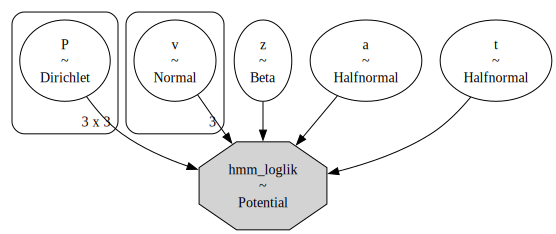

In [4]:
model = hssm.RSSSM(
    data=df, model="ddm", K=3, switching_params=["v"],
    v={"name": "Normal", "mu": 0.0, "sigma": 3.0},
    a={"name": "HalfNormal", "sigma": 2.0},
    z={"name": "Beta", "alpha": 10, "beta": 10},
    t={"name": "HalfNormal", "sigma": 0.5},
)
model.graph()

### Why label-switching control is *essential* at $K \ge 3$

The likelihood is invariant to any of the $K!$ relabellings of regimes, so the posterior has $K!$ equivalent modes. A natural fix is a **soft** constraint — a `pm.Potential` penalising mis-ordered draws. It happens to work at $K=2$ (one barrier, short trajectories), but **fails at $K\ge3$**: gradient-based NUTS trajectories jump across the penalty, chains settle in different label permutations, and you get inflated R-hat (≈1.3–2.2 in the design's experiments) and many divergences.

`RSSSM` instead parameterises the anchor `v` with PyMC's **`ordered` transform**, which maps to a strictly-ordered subspace — the permuted modes are *unreachable by construction*. This is what lets a single class scale cleanly from $K=2$ to arbitrary $K$.

## Part 4: Fit and check
---

In [5]:
idata = model.sample(draws=800, tune=800, chains=2, target_accept=0.9, random_seed=42)

/Users/fmuia/Library/CloudStorage/Dropbox/02-Data-Science/github-projects/HSSM/.venv/lib/python3.13/site-packages/pymc/sampling/jax.py:475: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(


/Users/fmuia/Library/CloudStorage/Dropbox/02-Data-Science/github-projects/HSSM/.venv/lib/python3.13/site-packages/jax/_src/interpreters/mlir.py:1178: UserWarning: Some donated buffers were not usable: ShapedArray(float64[2,800,3,2]).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [6]:
model.summary()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
z,0.495,0.017,0.466,0.528,0.000,0.000,1461.0,1283.0,1.0
"P[0, 0]",0.897,0.025,0.851,0.945,0.001,0.001,1447.0,1009.0,1.0
"P[0, 1]",0.041,0.022,0.003,0.080,0.001,0.001,874.0,657.0,1.0
"P[0, 2]",0.062,0.025,0.018,0.108,0.001,0.001,1608.0,972.0,1.0
"P[1, 0]",0.077,0.035,0.015,0.142,0.001,0.001,1347.0,940.0,1.0
"P[1, 1]",0.819,0.057,0.712,0.913,0.002,0.001,1361.0,1102.0,1.0
"P[1, 2]",0.103,0.053,0.018,0.201,0.001,0.001,1458.0,1216.0,1.0
"P[2, 0]",0.059,0.026,0.014,0.106,0.001,0.001,961.0,944.0,1.0
"P[2, 1]",0.088,0.037,0.022,0.153,0.001,0.001,728.0,885.0,1.0
"P[2, 2]",0.853,0.037,0.785,0.918,0.001,0.001,1889.0,1532.0,1.0


All three drift rates come back ordered and close to the true values, with no label-switching across chains:

In [7]:
def recovery_table(idata):
    v = idata.posterior["v"].mean(("chain", "draw")).values
    return pd.DataFrame({"regime": ["0 (conservative)", "1 (neutral)", "2 (eager)"],
                         "posterior mean v": np.round(v, 3), "true v": V_TRUE})
recovery_table(idata)

,regime,posterior mean v,true v
0,0 (conservative),-1.200,-1.0
1,1 (neutral),0.502,0.5
2,2 (eager),1.926,1.8


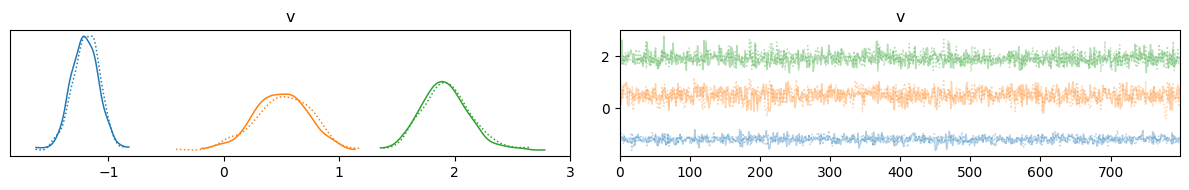

In [8]:
az.plot_trace(idata, var_names=["v"], compact=True); plt.tight_layout()

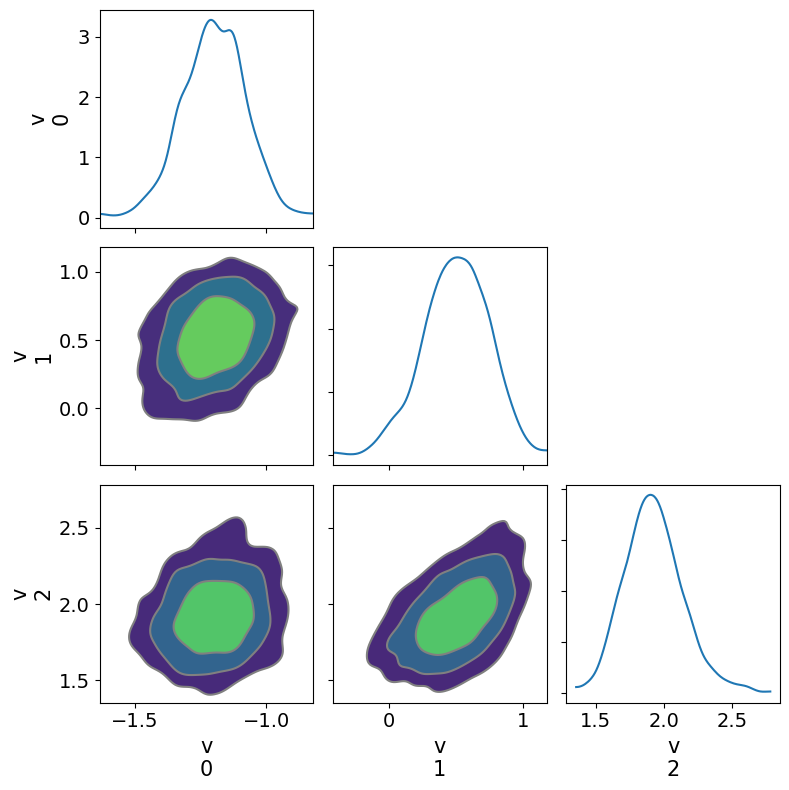

In [9]:
az.plot_pair(idata, var_names=["v"], kind="kde", marginals=True, figsize=(8, 8)); plt.tight_layout()

## Part 5: Recover the latent regimes (FFBS)
---
`infer_regimes` runs Forward-Filter Backward-Sample for a set of posterior draws and returns the per-trial posterior probability of each of the three regimes. `plot_regime_recovery` shows them as a stacked area against the ground truth.

In [10]:
regimes_idata = model.infer_regimes(idata, n_draws=200, seed=0)

Per-trial regime recovery accuracy: 88.4%


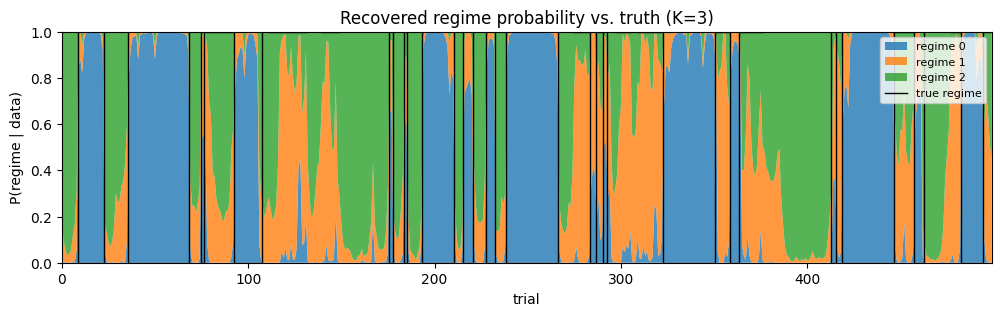

In [11]:
ax = model.plot_regime_recovery(regimes_idata, true_regimes=true_regimes)
ax.set_title("Recovered regime probability vs. truth (K=3)")
freq = regimes_idata.posterior_regimes["regime_sample_frequency"].values[0]
print(f"Per-trial regime recovery accuracy: {(freq.argmax(1) == true_regimes).mean():.1%}")

## Part 6: Other emission backends
---
Everything above uses the **analytical** DDM likelihood. As shown in full in the [K = 2 tutorial](rsssm_regime_switching.ipynb), switching to the **approximate-differentiable (LAN)** backend — needed for SSMs that have no analytical density, such as `angle` or `levy` — is a single keyword and leaves the rest of the workflow unchanged:

```python
model_lan = hssm.RSSSM(
    data=df, model="ddm", K=3, switching_params=["v"],
    loglik_kind="approx_differentiable", backend="jax",   # <- the only change
    v={"name": "Normal", "mu": 0.0, "sigma": 3.0},
)
idata_lan = model_lan.sample()
```

We keep the analytical backend here for speed (the LAN network is heavier to evaluate, more so at larger $K$); the K=2 tutorial demonstrates the analytical-vs-LAN agreement explicitly.

## Part 7: Transition-matrix recovery and RT by regime
---
The $3\times3$ transition matrix is recovered against its true values (dashed), and the observed signed RTs split cleanly by the regime FFBS assigns — three distinct, ordered bands.

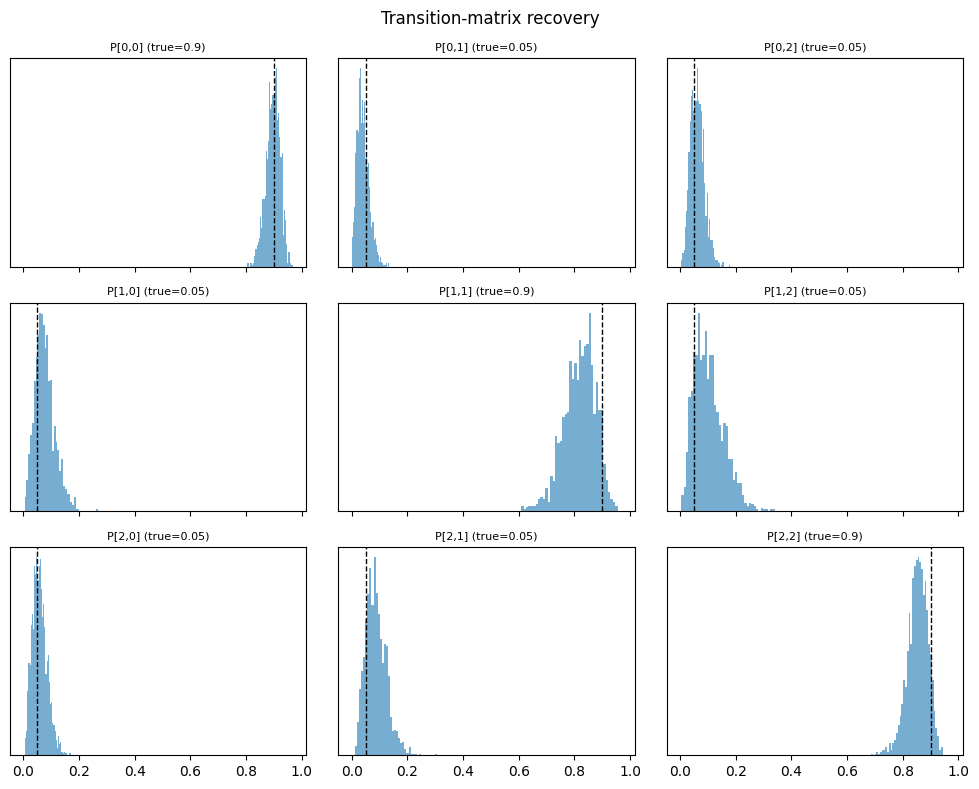

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(10, 8), sharex=True)
for i in range(3):
    for j in range(3):
        ax = axes[i, j]
        ax.hist(idata.posterior["P"].values[..., i, j].ravel(), bins=40, density=True,
                alpha=0.6, color="C0")
        ax.axvline(P_TRUE[i, j], color="k", ls="--", lw=1)
        ax.set_title(f"P[{i},{j}] (true={P_TRUE[i, j]})", fontsize=8); ax.set_yticks([])
fig.suptitle("Transition-matrix recovery"); fig.tight_layout()

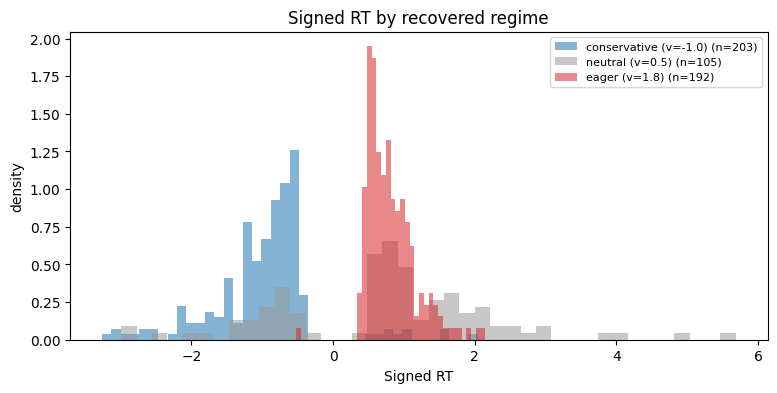

In [13]:
map_regime = freq.argmax(1)
fig, ax = plt.subplots(figsize=(9, 4))
for k in (0, 1, 2):
    sr = (df["rt"].values * df["response"].values)[map_regime == k]
    ax.hist(sr, bins=40, alpha=0.55, color=colors[k], density=True,
            label=f"{names[k]} (n={len(sr)})")
ax.set_xlabel("Signed RT"); ax.set_ylabel("density"); ax.legend(fontsize=8)
ax.set_title("Signed RT by recovered regime"); plt.show()

## Part 8: How many regimes? Model selection with LOO
---
*New with the class.* In practice you rarely know $K$ in advance. Because `compute_log_likelihood` reconstructs per-trial log-likelihoods, you can fit several values of $K$ and compare them with **LOO cross-validation**. Here we fit a $K=2$ model to the *same* three-regime data and compare it to the $K=3$ fit — we expect $K=3$ to be preferred, since two regimes cannot represent the third drift state.

> **Caveat.** LOO assumes conditionally-independent observations; HMM trials are dependent, so treat the comparison as a guide rather than a strict test, and corroborate with posterior predictive checks.

In [14]:
model_k2 = hssm.RSSSM(
    data=df, model="ddm", K=2, switching_params=["v"],
    v={"name": "Normal", "mu": 0.0, "sigma": 3.0},
    a={"name": "HalfNormal", "sigma": 2.0},
    z={"name": "Beta", "alpha": 10, "beta": 10},
    t={"name": "HalfNormal", "sigma": 0.5},
)
idata_k2 = model_k2.sample(draws=800, tune=800, chains=2, target_accept=0.9, random_seed=42)
model_k2.compute_log_likelihood(idata_k2)
model.compute_log_likelihood(idata)
az.compare({"K=2": idata_k2, "K=3": idata})

No participant column found; treating all rows as a single participant.


RSSSM model initialized successfully.


/Users/fmuia/Library/CloudStorage/Dropbox/02-Data-Science/github-projects/HSSM/.venv/lib/python3.13/site-packages/pymc/sampling/jax.py:475: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(


/Users/fmuia/Library/CloudStorage/Dropbox/02-Data-Science/github-projects/HSSM/.venv/lib/python3.13/site-packages/jax/_src/interpreters/mlir.py:1178: UserWarning: Some donated buffers were not usable: ShapedArray(float64[2,800,2,1]).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"


We recommend running at least 4 chains for robust computation of convergence diagnostics


Reconstructing per-trial log-likelihood over 1600 draws (2 chains x 800) for 1 participants; this can be slow on large posteriors.


Reconstructing per-trial log-likelihood over 1600 draws (2 chains x 800) for 1 participants; this can be slow on large posteriors.


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
K=3,0,-510.760243,9.934546,0.000000,0.97106,26.942941,0.000000,False,log
K=2,1,-521.202763,7.556504,10.442521,0.02894,27.948347,4.981921,False,log


The $K=3$ model has the higher expected log predictive density — the data support three regimes, as simulated. The same recipe (fit a grid of $K$, compare LOO) is how you would choose the number of regimes on real data.

## Part 9: Summary and extensions
---
### What we did
- Ran the regime-switching workflow at **$K = 3$** for a single participant — simulation, forward-algorithm likelihood, NUTS, FFBS recovery, transition-matrix recovery, and RT-by-regime — all via `RSSSM`.
- Saw *why* the `ordered`-transform anchor is essential at $K \ge 3$, where a soft constraint fails.
- Used **LOO** to select the number of regimes ($K=3$ over $K=2$).

### Where to go next
- **The full analytical-vs-LAN comparison and per-regime lapses** are in the [K = 2 tutorial](rsssm_regime_switching.ipynb).
- **More switching parameters:** `switching_params=["v", "a"]`.
- **Any SSM:** swap `model="ddm"` for `"angle"`, `"levy"`, … (analytical or LAN).
- **Multiple participants:** `RSSSM` fits panels too (`participant_col=...`), with shared (`pooling="full"`) or independent (`"none"`) regime parameters; hierarchical pooling is a planned extension.